<h1 style="text-align: center; color: purple;">End-to-End Credit Risk MLOps System</h1>

<h2 style="text-align: center; color: green;">Phase 1: Credit Risk Model Development</h2>

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### **Read data from CSV files**

In [123]:
df_customers = pd.read_csv("data/dataset_1.csv")
df_loans = pd.read_csv("data/dataset_2.csv")
df_bureau = pd.read_csv("data/dataset_3.csv")

In [124]:
df_customers.shape

(50000, 12)

In [125]:
df_loans.shape

(50000, 15)

In [126]:
df_bureau.shape

(50000, 8)

In [127]:
df_customers.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [128]:
df_loans.head(5)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.000,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.000,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.000,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [129]:
df_bureau.head(5)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [130]:
df = pd.merge(df_customers, df_loans, on='cust_id')

In [131]:
df.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.000,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.000,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.000,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [132]:
df = pd.merge(df, df_bureau, on='cust_id')

In [133]:
df.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [135]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

The `default` column is the target variable. As shown by the class distribution, the dataset exhibits class imbalance, with significantly more non-default cases (`0`) than default cases (`1`). We will address this imbalance during the model-building phase using appropriate techniques.

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

### **Train Test split**

We perform the train-test split before EDA to prevent data leakage. This ensures that the test set remains unseen during exploratory analysis and feature engineering, allowing for an unbiased evaluation of the model.

In [137]:
X = df.drop("default", axis="columns")
y = df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

In [138]:
df_train.head(5)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-06-18,2020-07-07,3,0,76,0,0,8,87,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-11-12,2020-12-07,1,2,60,0,0,1,71,0


#### **1. Data Cleaning**

**1.1 Handle Missing & Duplicate Values**

In [139]:
df_train.shape

(37500, 33)

In [140]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [141]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [142]:
df_train["residence_type"].value_counts(dropna=False)

residence_type
Owned       21133
Mortgage     8858
Rented       7462
NaN            47
Name: count, dtype: int64

In [143]:
df_test["residence_type"].value_counts(dropna=False)

residence_type
Owned       7105
Mortgage    2961
Rented      2419
NaN           15
Name: count, dtype: int64

In [144]:
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [145]:
df_train["residence_type"] = df_train["residence_type"].fillna(mode_residence)
df_test["residence_type"] = df_test["residence_type"].fillna(mode_residence)

df_train["residence_type"].unique(), df_test["residence_type"].unique()

(array(['Owned', 'Mortgage', 'Rented'], dtype=object),
 array(['Owned', 'Mortgage', 'Rented'], dtype=object))

In [146]:
df_train.duplicated().sum()

np.int64(0)

In [147]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,...,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000,37500.000
mean,39.541,2633326.160,1.945,15.998,418866.253,4699691.573,3996067.733,80290.677,719292.192,3196854.187,...,1333819.515,986298.868,2.503,1.001,76.111,4.845,26.673,5.009,43.425,0.086
std,9.858,2623780.517,1.536,8.921,169035.022,6257832.982,5371862.293,113128.140,966935.213,4297489.834,...,1213674.444,1043145.014,1.119,0.814,43.769,5.841,32.779,2.029,29.393,0.280
min,18.000,0.000,0.000,1.000,110001.000,0.000,0.000,0.000,0.000,0.000,...,-1.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
25%,33.000,802000.000,0.000,8.000,302001.000,1142000.000,961000.000,19220.000,172980.000,768800.000,...,422197.500,287040.250,1.000,0.000,42.000,0.000,0.000,4.000,18.000,0.000
50%,39.000,1885000.000,2.000,16.000,400001.000,2644000.000,2230000.000,44600.000,401400.000,1784000.000,...,997427.500,665014.500,3.000,1.000,71.000,3.000,13.000,5.000,39.000,0.000
75%,46.000,3326250.000,3.000,24.000,560001.000,5178000.000,4619000.000,92420.000,831420.000,3695200.000,...,1784879.000,1234062.750,4.000,2.000,107.000,8.000,46.000,6.000,67.000,0.000
max,70.000,11999000.000,5.000,31.000,700001.000,52175000.000,47819000.000,5293543.524,8607420.000,38255200.000,...,5000000.000,7846643.000,4.000,2.000,223.000,24.000,171.000,9.000,99.000,1.000


In [148]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [149]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address',
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement',
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city',
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

**1.2 Box plot to visualize outliers**

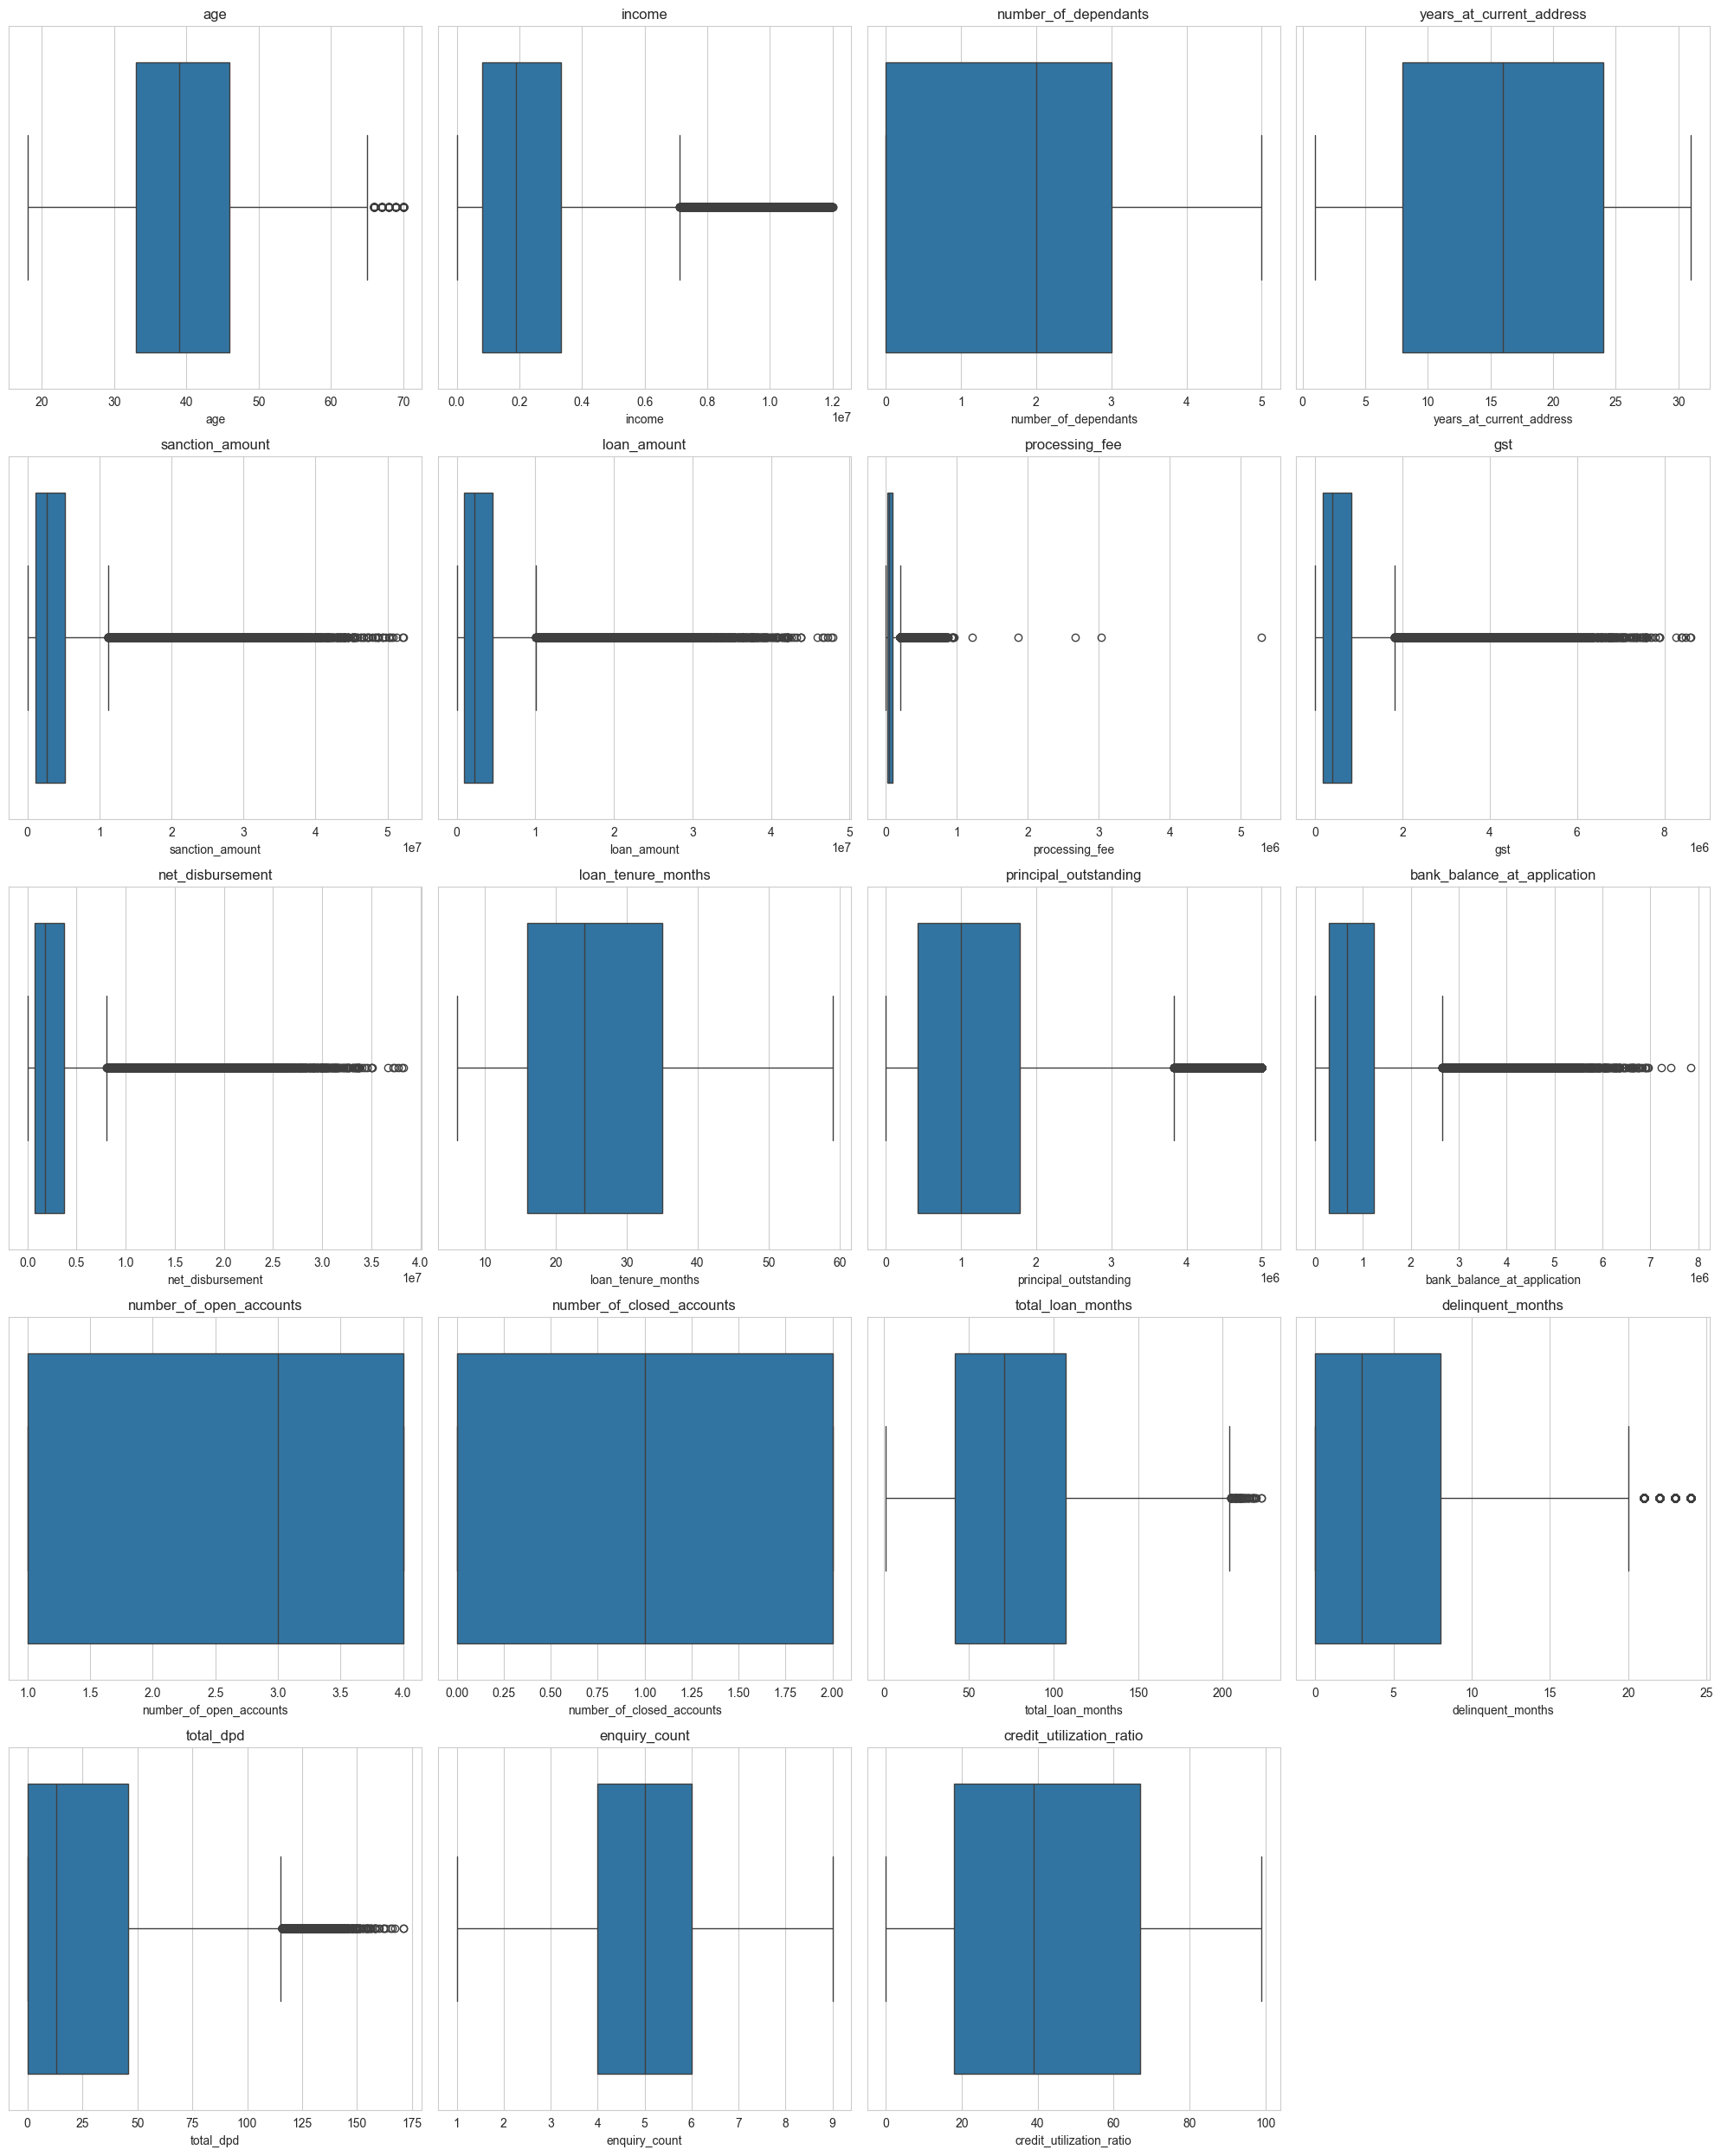

In [150]:
num_plots = len(columns_continuous)
plots_per_row = 4
num_rows = (num_plots + plots_per_row - 1) // plots_per_row

# Create a grid of subplots
fig, axes = plt.subplots(nrows=num_rows,ncols=plots_per_row,figsize=(5 * plots_per_row, 5 * num_rows))

# Flatten the axes array for easy iteration
axes = axes.ravel()

# Generate a box plot for each continuous feature
for ax, col in zip(axes, columns_continuous):
    sns.boxplot(x=df_train[col], ax=ax)
    ax.set_title(col)

# Hide any unused subplots
for ax in axes[num_plots:]:
    ax.set_visible(False)

# Adjust spacing and display the plots
plt.tight_layout()
plt.show()

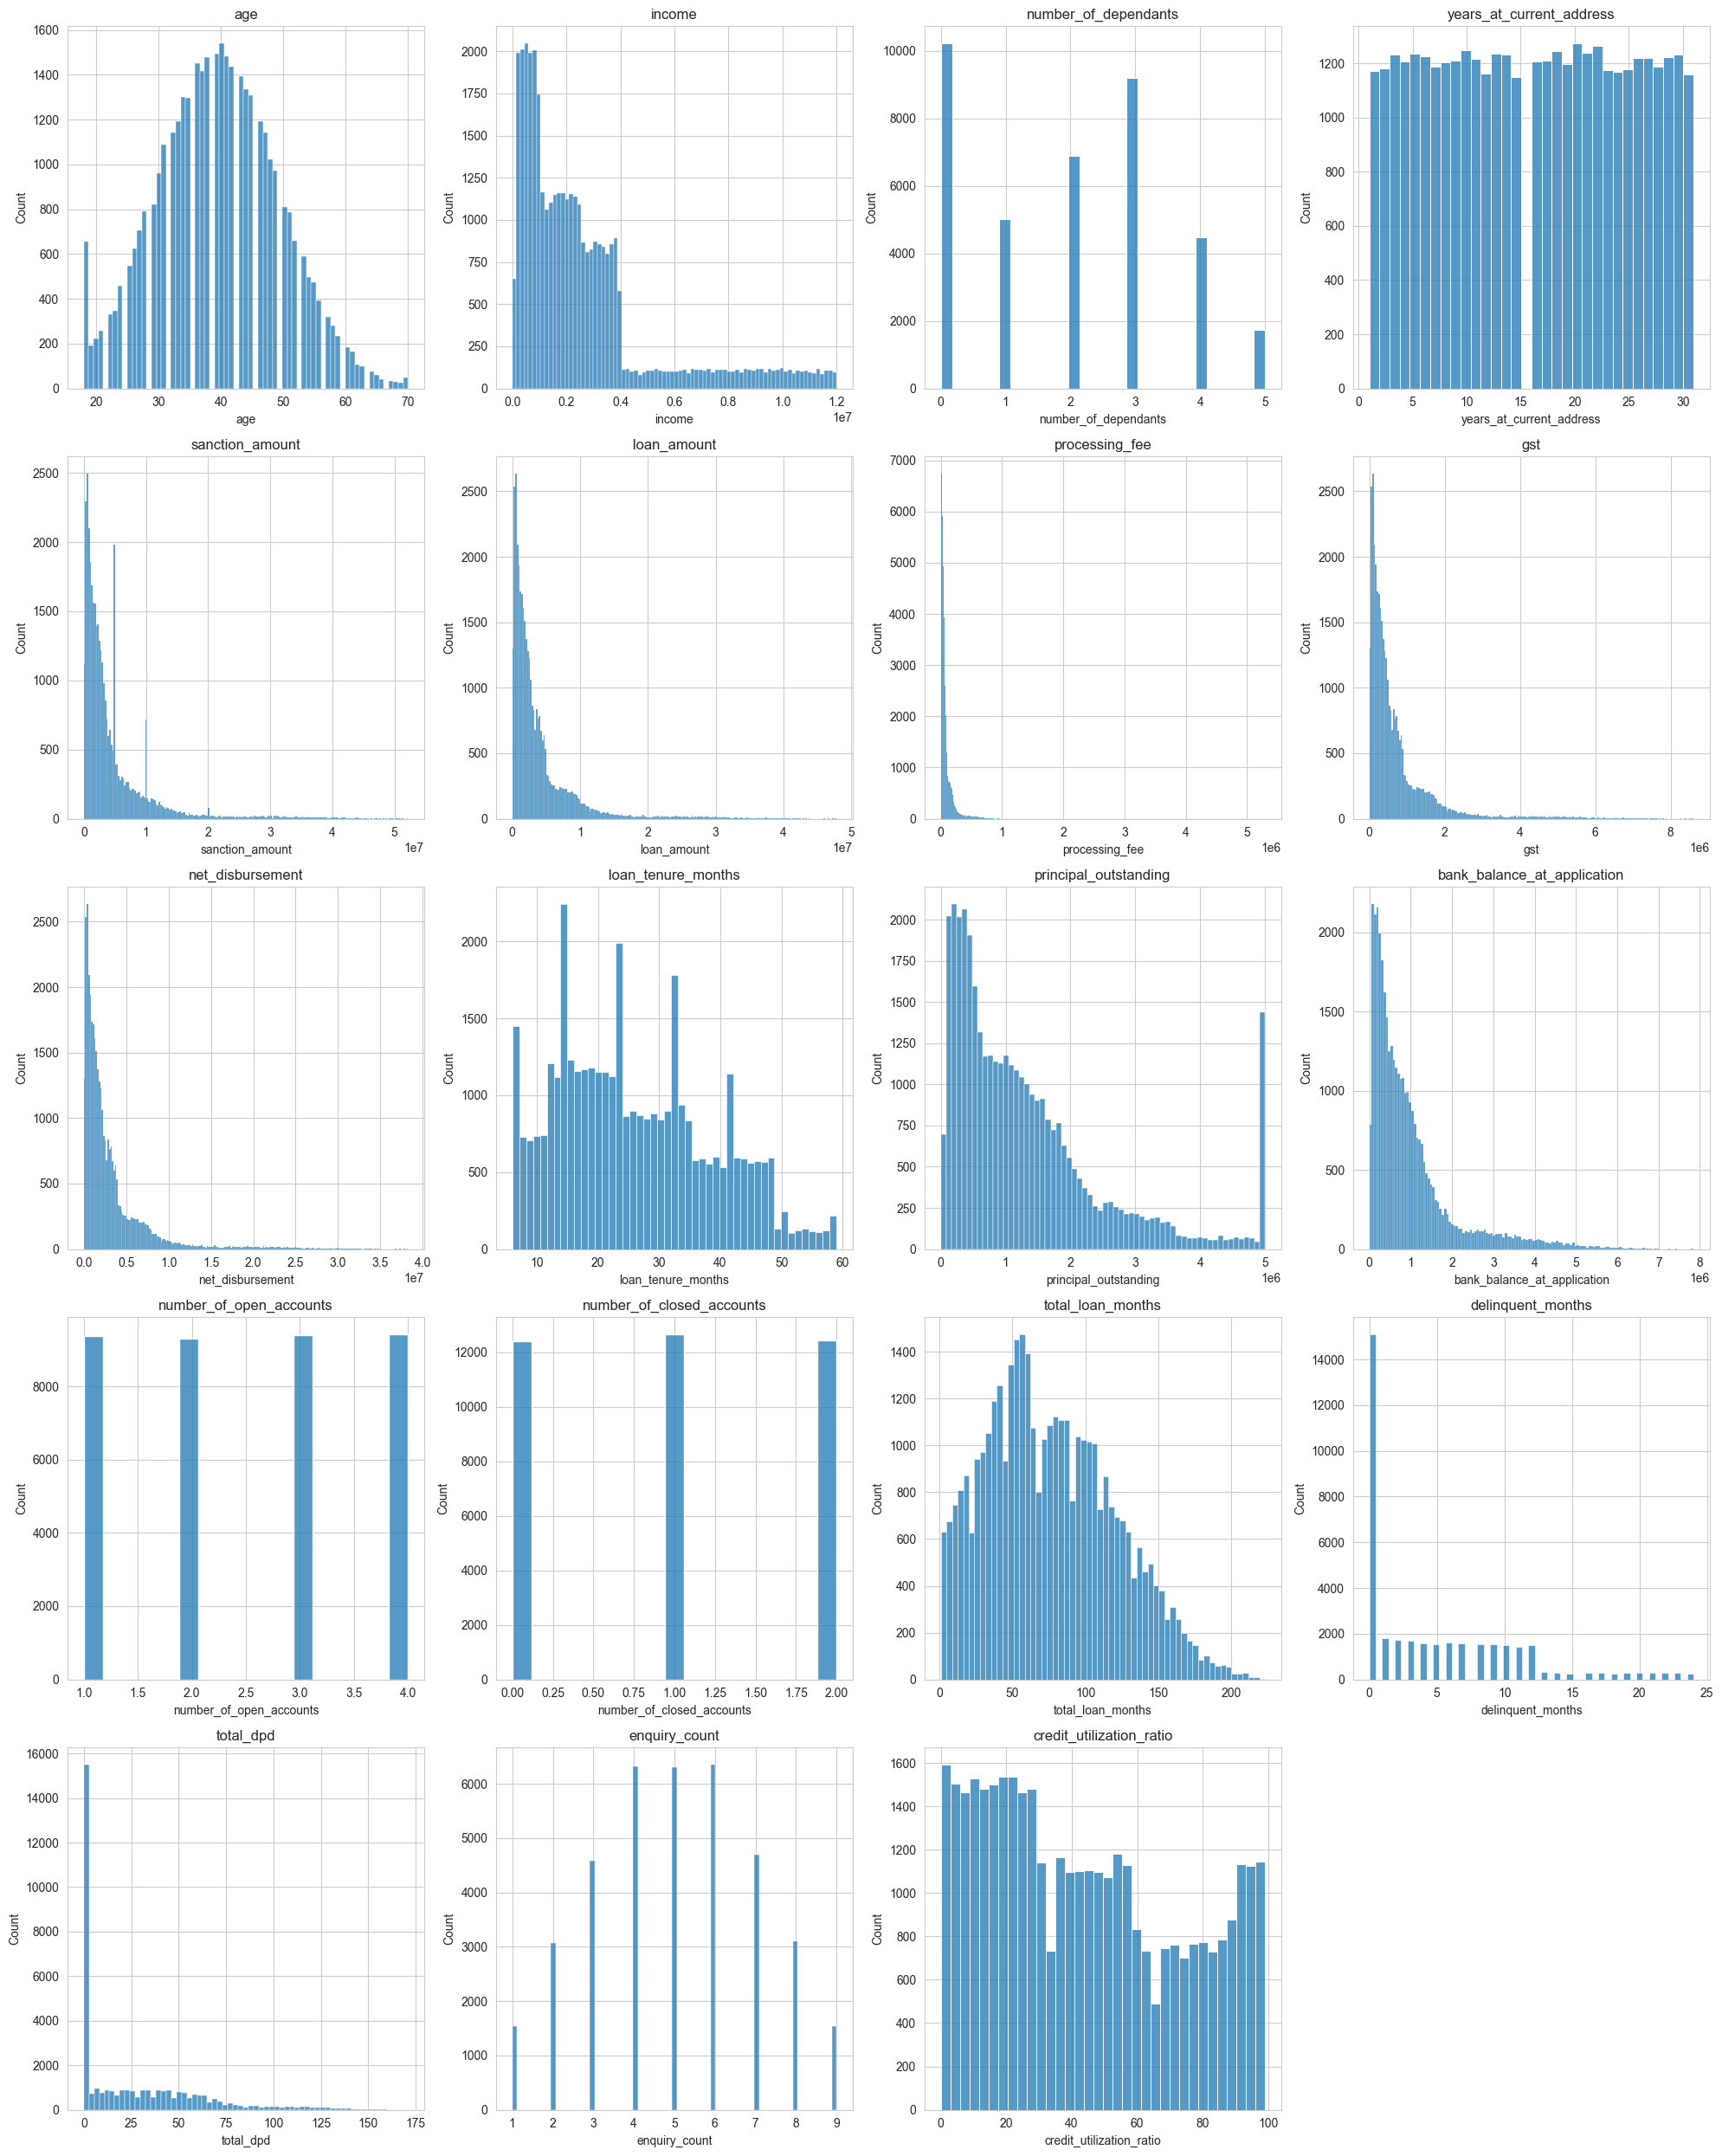

In [151]:
num_plots = len(columns_continuous)
plots_per_row = 4
num_rows = (num_plots + plots_per_row - 1) // plots_per_row

# Create a grid of subplots
fig, axes = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(5 * plots_per_row, 5 * num_rows)
)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot the distribution of each continuous feature
for ax, col in zip(axes, columns_continuous):
    sns.histplot(df_train[col], ax=ax)
    ax.set_title(col)

# Hide any unused subplots
for ax in axes[num_plots:]:
    ax.axis("off")

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

**1.3 Outlier Removal: Processing Fee**

In [152]:
df_train["processing_fee"].describe().round(2)

count     37500.000
mean      80290.680
std      113128.140
min           0.000
25%       19220.000
50%       44600.000
75%       92420.000
max     5293543.520
Name: processing_fee, dtype: float64

In [153]:
# Display loans where the processing fee exceeds 3% of the loan amount
df_train[
    (df_train.processing_fee / df_train.loan_amount) > 0.03
][["loan_amount", "processing_fee"]].round(2)

,loan_amount,processing_fee
23981,2234000,2669791.020
28174,966000,1214492.670
47089,1738000,1858964.770
29305,2616000,3036378.010
9898,3626000,5293543.520


In [154]:
df_train_1 = df_train[df_train.processing_fee/df_train.loan_amount<0.03].copy()
df_train_1.shape

(37488, 33)

In [155]:
df_test.residence_type.isna().sum()

np.int64(0)

In [156]:
# Apply same step on test set
df_test = df_test[df_test.processing_fee/df_test.loan_amount<0.03].copy()
df_test.shape

(12497, 33)

In [157]:
# Validate the dataset using additional business rules
# Rule 1: GST should not exceed 20% of the loan amount

df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2].shape

(0, 33)

In [158]:
# Rule 2: Net disbursement should not be higher than loan_amount
df_train_1[df_train_1.net_disbursement>df_train_1.loan_amount].shape

(0, 33)

No records violate either of the above business rules.

**1.4 Analyze Categorical Columns**

In [159]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [160]:
for col in columns_categorical:
    print(col, "-->", df_train_1[col].unique())

gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode --> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


**1.5 Fix Errors in Loan Purpose Column**

In [161]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_train_1['loan_purpose'].unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [162]:
df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal', 'Personal')
df_test['loan_purpose'].unique()

array(['Home', 'Education', 'Auto', 'Personal'], dtype=object)

#### **2. Exploratory Data Analysis**

In [163]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

**2.1 Age Column**

In [164]:
df_train_1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.000,39.768,9.880,18.000,33.000,40.000,46.000,70.000
1,3223.000,37.125,9.290,18.000,31.000,37.000,44.000,70.000


**Insights**

* The average age in the default group (37.12 years) is slightly lower than that of the non-default group (39.77 years).
* The variability (standard deviation) is similar across both groups.
* Both groups have the same minimum (18 years) and maximum (70 years) ages.

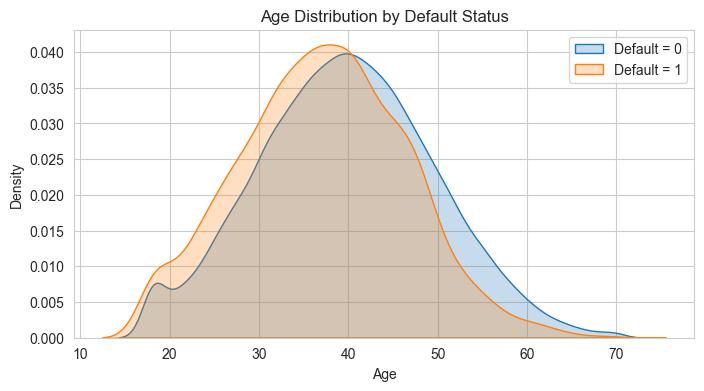

In [165]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 0, "age"],
    fill=True,
    label="Default = 0"
)

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 1, "age"],
    fill=True,
    label="Default = 1"
)

# Customize the plot
plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

plt.show()

**Insights**

* The distribution of defaulted customers (orange) is slightly shifted to the left compared to non-defaulted customers (blue), indicating that younger individuals are more likely to default.

**2.2 KDE for all the Columns**

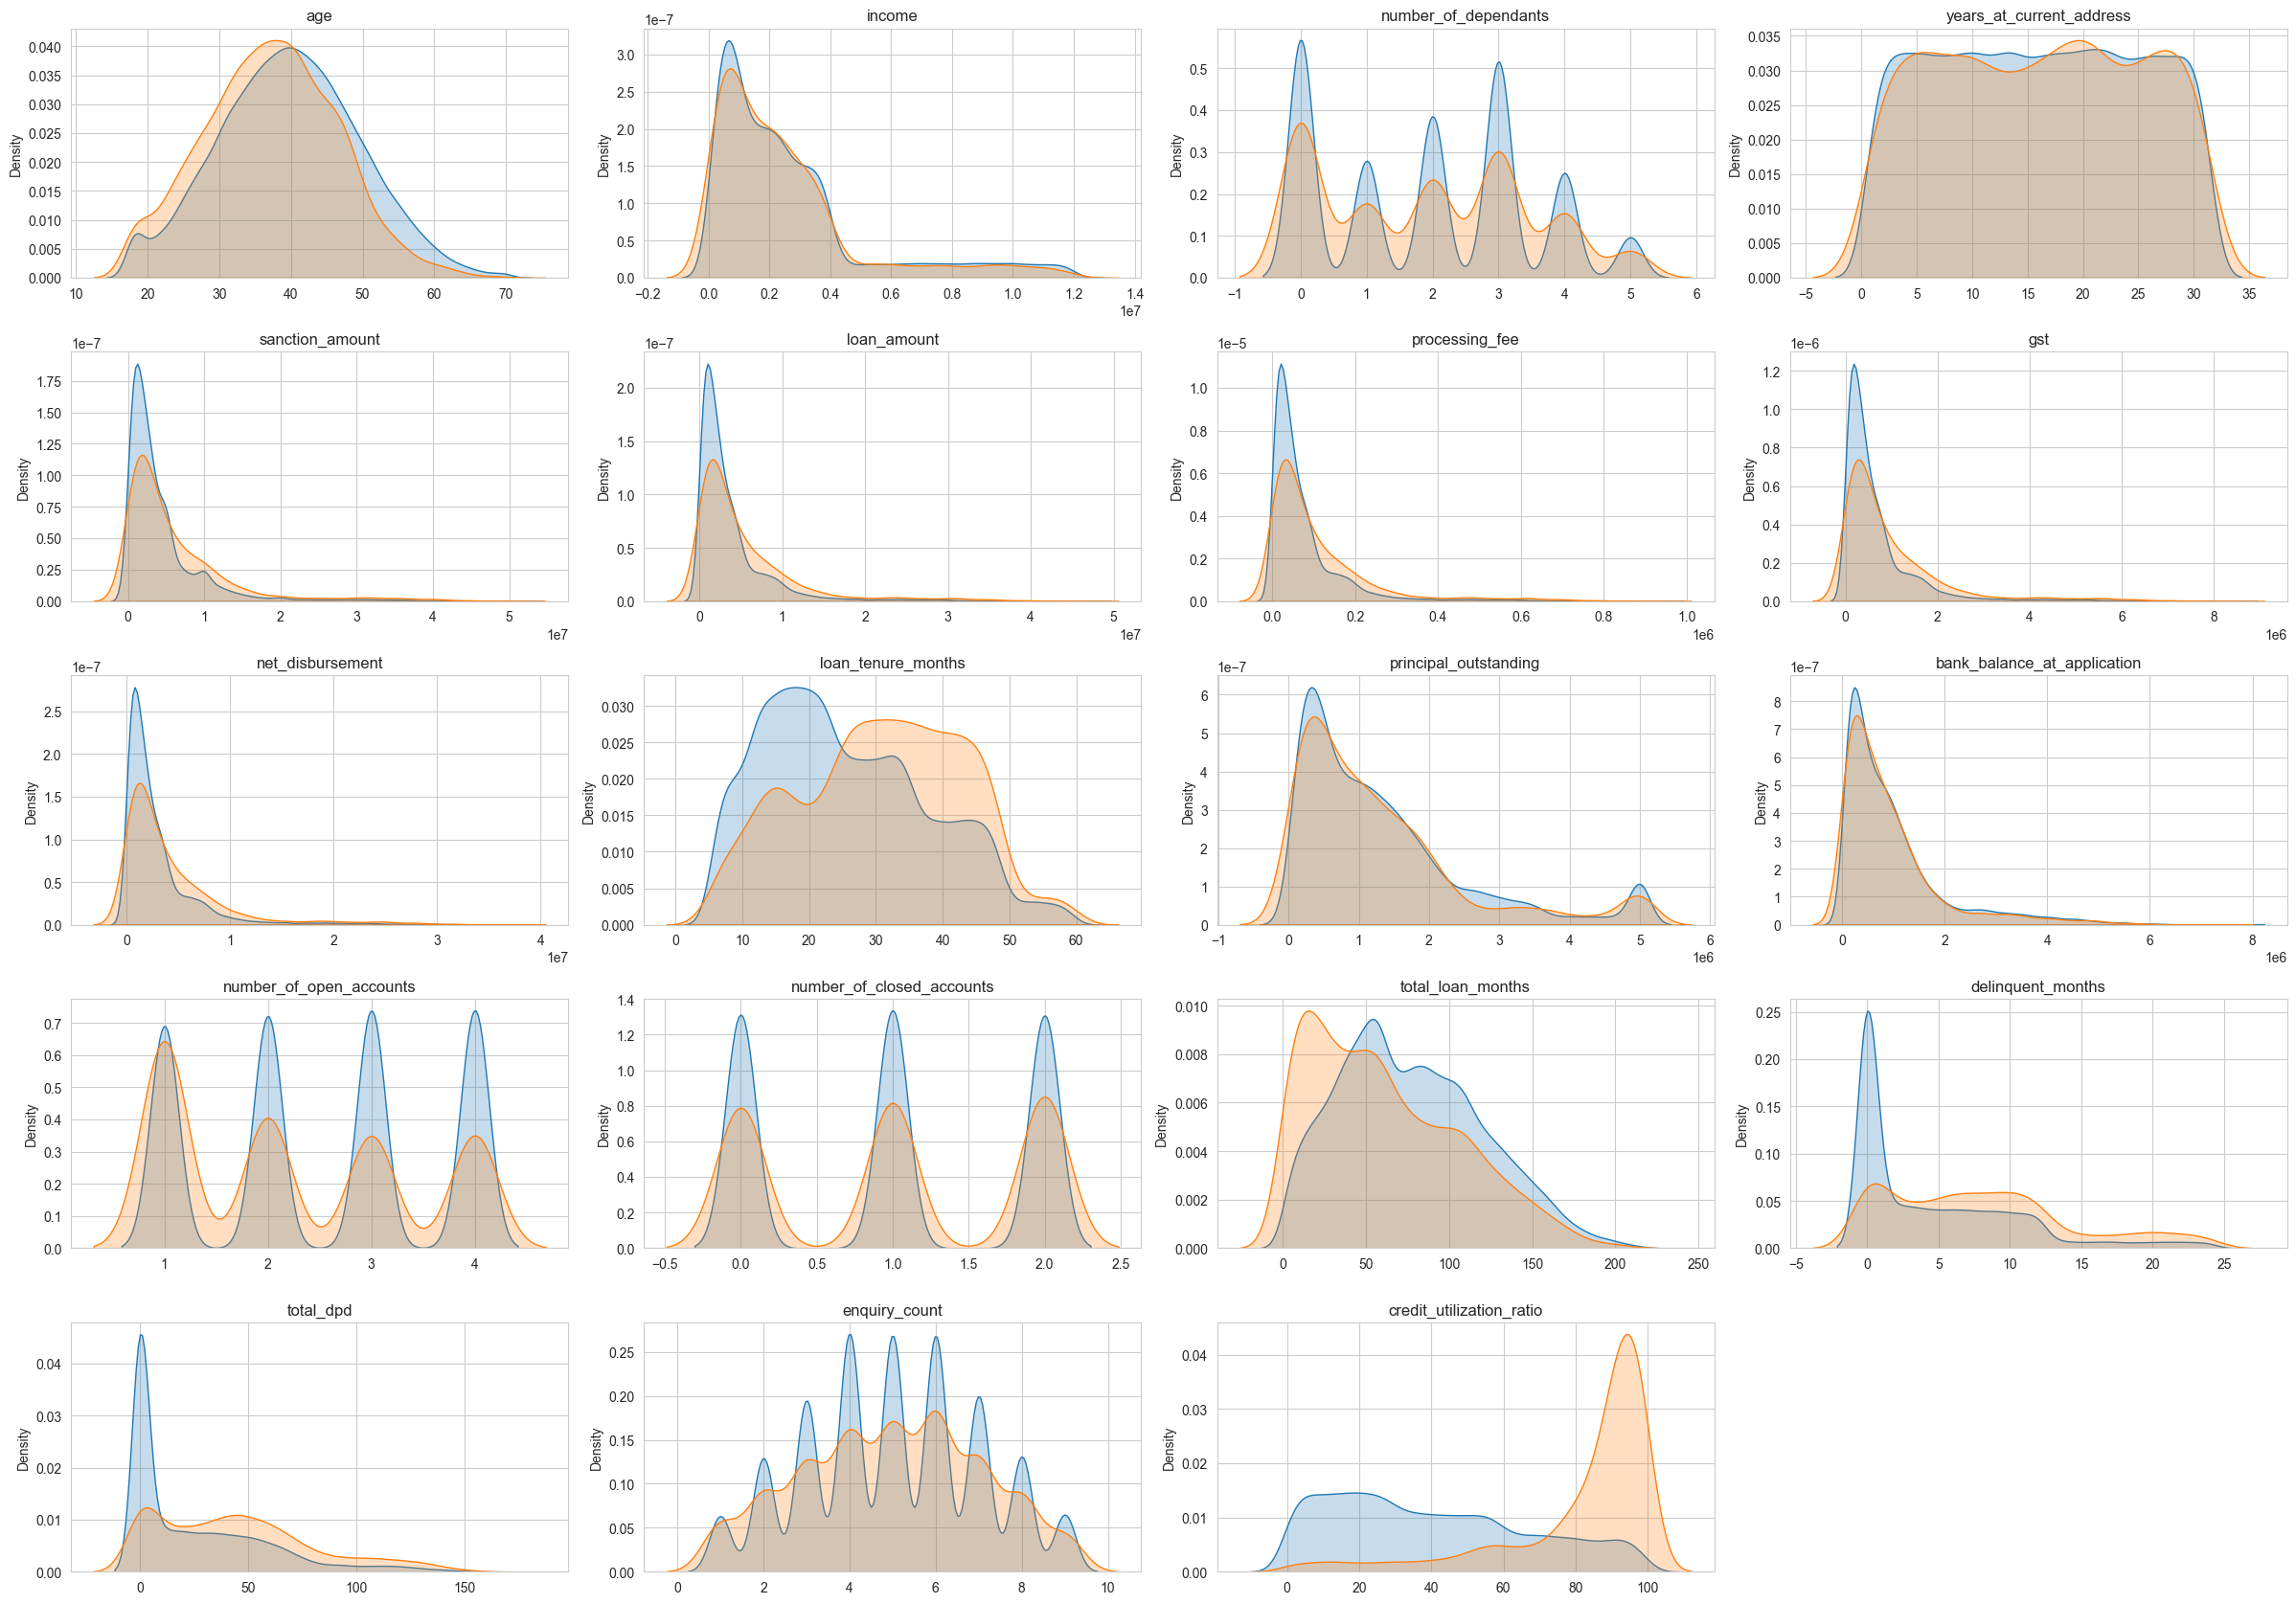

In [166]:
plt.figure(figsize=(24, 20))

for i, col in enumerate(columns_continuous):
    # Create a subplot for each continuous feature
    plt.subplot(6, 4, i + 1)

    sns.kdeplot(
        df_train_1.loc[df_train_1["default"] == 0, col],
        fill=True,
        label="Default = 0"
    )
    sns.kdeplot(
        df_train_1.loc[df_train_1["default"] == 1, col],
        fill=True,
        label="Default = 1"
    )

    # Add plot title and remove the x-axis label
    plt.title(col)
    plt.xlabel("")

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

**Insights**

* The distributions of **loan_tenure_months**, **delinquent_months**, **total_dpd**, and **credit_utilization_ratio** indicate that higher values are associated with an increased likelihood of loan default. These features appear to be strong predictors of the target variable.
* The remaining continuous features do not show a clear distinction between the default and non-default groups, suggesting that they have limited predictive power when considered individually.
* Neither **loan_amount** nor **income** appears to be a strong standalone predictor of loan default. However, their combined effect, represented by the **Loan-to-Income (LTI) ratio**, may provide greater predictive value. This relationship will be explored further during the feature engineering stage.

#### **3. Feature Engineering, Feature Selection**

**3.1 Generate Loan to Income (LTI) Ratio**

In [167]:
df_train_1[["loan_amount", "income"]].head(5)

,loan_amount,income
12746,23442000,11327000
32495,1149000,715000
43675,11296000,3195000
9040,1695000,1500000
13077,905000,1817000


In [168]:
df_train_1['loan_to_income'] = round(df_train_1['loan_amount'] / df_train_1['income'],2)
df_train_1['loan_to_income'].describe()

count   37488.000
mean        1.557
std         0.974
min         0.300
25%         0.770
50%         1.160
75%         2.460
max         4.570
Name: loan_to_income, dtype: float64

In [169]:
df_test['loan_to_income'] = round(df_test['loan_amount'] / df_test['income'],2)

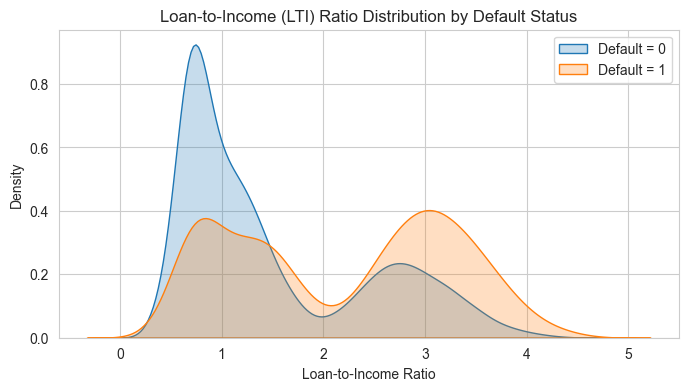

In [170]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 0, "loan_to_income"],
    fill=True,
    label="Default = 0"
)

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 1, "loan_to_income"],
    fill=True,
    label="Default = 1"
)

# Customize the plot
plt.title("Loan-to-Income (LTI) Ratio Distribution by Default Status")
plt.xlabel("Loan-to-Income Ratio")
plt.ylabel("Density")
plt.legend()

plt.show()

**Insights**

* The non-default group (blue curve) is concentrated at lower Loan-to-Income (LTI) ratios.
* The default group (orange curve) has a higher concentration of borrowers with elevated LTI ratios, indicating that a higher LTI is associated with an increased likelihood of loan default.

**3.2 Generate Delinquency Ratio**

In [171]:
df_train_1['delinquency_ratio'] = (df_train_1['delinquent_months']*100 / df_train_1['total_loan_months']).round(2)
df_test['delinquency_ratio'] = (df_test['delinquent_months']*100 / df_test['total_loan_months']).round(2)

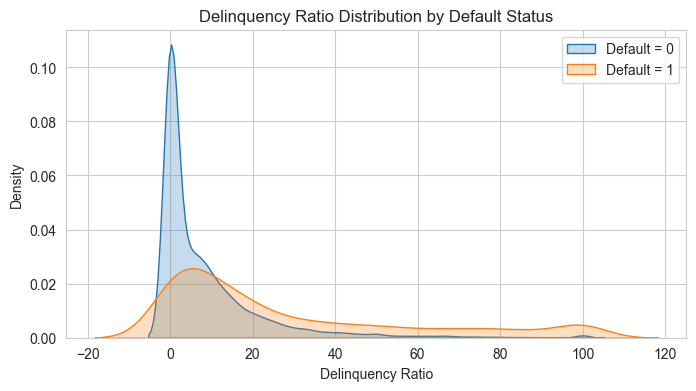

In [172]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 0, "delinquency_ratio"],
    fill=True,
    label="Default = 0"
)

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 1, "delinquency_ratio"],
    fill=True,
    label="Default = 1"
)

# Customize the plot
plt.title("Delinquency Ratio Distribution by Default Status")
plt.xlabel("Delinquency Ratio")
plt.ylabel("Density")
plt.legend()

plt.show()

**Insights**

* The non-default group (blue curve) is concentrated at lower delinquency ratios.
* The default group (orange curve) has a higher concentration of borrowers with elevated delinquency ratios, indicating that a higher delinquency ratio is associated with an increased likelihood of loan default.

**3.3 Generate Avg DPD Per Delinquency**

In [173]:
df_train_1['avg_dpd_per_delinquency'] = np.where(
    df_train_1['delinquent_months'] != 0,
    (df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(2),
    0
)

df_test['avg_dpd_per_delinquency'] = np.where(
    df_test['delinquent_months'] != 0,
    (df_test['total_dpd'] / df_test['delinquent_months']).round(2),
    0
)

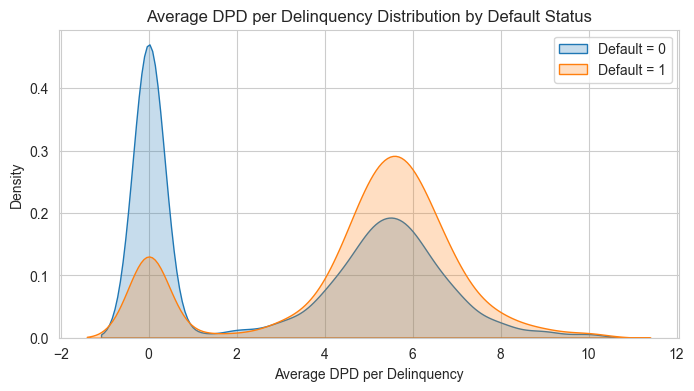

In [174]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 0, "avg_dpd_per_delinquency"],
    fill=True,
    label="Default = 0"
)

sns.kdeplot(
    df_train_1.loc[df_train_1["default"] == 1, "avg_dpd_per_delinquency"],
    fill=True,
    label="Default = 1"
)

# Customize the plot
plt.title("Average DPD per Delinquency Distribution by Default Status")
plt.xlabel("Average DPD per Delinquency")
plt.ylabel("Density")
plt.legend()

plt.show()

**Insights**

* The distribution shows a higher concentration of default cases at higher values of **avg_dpd_per_delinquency**.
* This indicates that **avg_dpd_per_delinquency** is a strong predictor of loan default.

**3.4 Feature Selection: Remove columns that are just unique ids and don't have influence on target**

In [175]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [176]:
df_train_2 = df_train_1.drop(['cust_id', 'loan_id'],axis="columns")
df_test = df_test.drop(['cust_id', 'loan_id'],axis="columns")

**3.5 Feature Selection: Remove columns that business contact person asked us to remove**

In [177]:
df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income',
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income',
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [178]:
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

**3.6 VIF to measure multicolinearity**

In [179]:
X_train = df_train_3.drop("default", axis="columns")
y_train = df_train_3["default"]

from sklearn.preprocessing import MinMaxScaler

# Identify the numerical features to scale
cols_to_scale = X_train.select_dtypes(include=["int64", "float64"]).columns

# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Scale the numerical features
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Display the summary statistics of the scaled features
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000,37488.000
mean,0.414,0.389,0.500,0.524,0.089,0.083,0.083,0.083,0.377,0.262,0.124,0.501,0.501,0.501,0.439,0.294,0.103,0.328
std,0.190,0.307,0.297,0.286,0.120,0.112,0.112,0.112,0.235,0.244,0.133,0.373,0.407,0.254,0.297,0.228,0.173,0.291
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.288,0.000,0.233,0.325,0.021,0.019,0.019,0.019,0.189,0.078,0.034,0.000,0.000,0.375,0.182,0.110,0.000,0.000
50%,0.404,0.400,0.500,0.492,0.049,0.046,0.046,0.046,0.340,0.194,0.083,0.667,0.500,0.500,0.394,0.201,0.037,0.433
75%,0.538,0.600,0.767,0.763,0.098,0.096,0.096,0.096,0.547,0.352,0.155,1.000,1.000,0.625,0.677,0.506,0.130,0.574
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


**3.7 Same transformation on test set**

In [180]:
X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000,12497.000
mean,0.415,0.385,0.503,0.525,0.089,0.083,0.083,0.083,0.375,0.265,0.125,0.497,0.500,0.501,0.436,0.293,0.106,0.334
std,0.189,0.307,0.298,0.286,0.121,0.113,0.113,0.113,0.234,0.245,0.135,0.373,0.407,0.254,0.295,0.226,0.173,0.290
min,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.288,0.000,0.233,0.325,0.021,0.019,0.019,0.019,0.189,0.080,0.034,0.000,0.000,0.375,0.182,0.112,0.000,0.000
50%,0.423,0.400,0.500,0.510,0.050,0.046,0.046,0.046,0.340,0.198,0.084,0.333,0.500,0.500,0.394,0.201,0.042,0.440
75%,0.538,0.600,0.767,0.763,0.097,0.095,0.095,0.095,0.547,0.357,0.158,0.667,1.000,0.625,0.677,0.499,0.134,0.575
max,1.000,1.000,1.000,1.000,0.981,0.964,0.964,0.964,1.000,1.000,0.939,1.000,1.000,1.000,1.000,1.005,1.000,1.000


In [181]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [182]:
X_train.head(5)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.788,M,Married,Self-Employed,0.600,Owned,0.967,Hyderabad,Telangana,0.661,...,0.415,1.000,0.613,1.000,1.000,0.375,0.364,0.415,0.132,0.590
32495,0.500,F,Single,Salaried,0.000,Owned,0.867,Mumbai,Maharashtra,0.492,...,0.830,0.087,0.025,0.667,0.500,0.500,0.051,0.307,0.062,0.620
43675,0.385,M,Single,Salaried,0.000,Mortgage,0.833,Chennai,Tamil Nadu,0.831,...,0.491,0.327,0.174,0.000,0.500,0.375,0.000,0.759,0.222,0.558
9040,0.462,M,Married,Salaried,0.400,Mortgage,0.967,Bangalore,Karnataka,0.763,...,0.642,0.199,0.078,0.667,0.000,0.875,0.879,0.194,0.000,0.000
13077,0.769,M,Married,Self-Employed,0.800,Owned,0.933,Pune,Maharashtra,0.510,...,0.170,0.124,0.072,0.000,1.000,0.000,0.717,0.047,0.000,0.000


In [183]:
calculate_vif(X_train[cols_to_scale])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.701
1,number_of_dependants,2.730
2,years_at_current_address,3.423
3,zipcode,3.798
4,sanction_amount,101.087
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.181
9,principal_outstanding,16.326


In [184]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [185]:
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Column,VIF
0,age,5.429
1,number_of_dependants,2.727
2,years_at_current_address,3.404
3,zipcode,3.778
4,loan_tenure_months,6.019
5,bank_balance_at_application,1.805
6,number_of_open_accounts,4.353
7,number_of_closed_accounts,2.372
8,enquiry_count,6.384
9,credit_utilization_ratio,2.920


In [186]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'], dtype=object)

In [187]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

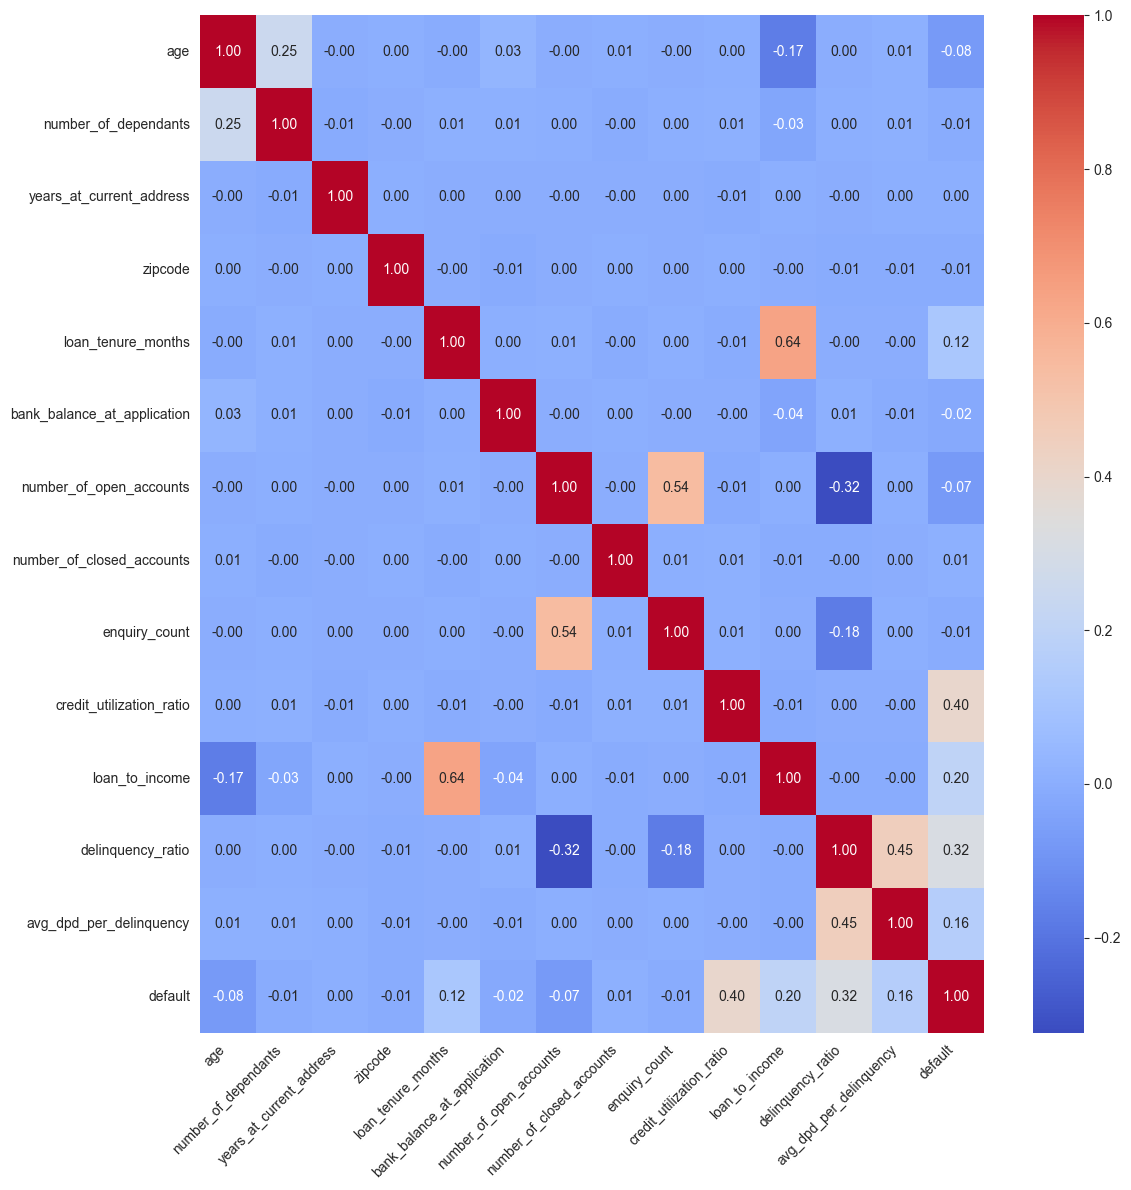

In [188]:
corr_matrix = df_train_3[numeric_columns.append(pd.Index(["default"]))].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Improve the readability of axis labels
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Adjust the layout and display the heatmap
plt.tight_layout()
plt.show()

**3.8 Feature Selection: Categorical Features**

In [189]:
X_train_1.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.788,M,Married,Self-Employed,0.600,Owned,0.967,Hyderabad,Telangana,0.661,...,Secured,0.415,0.613,1.000,1.000,0.375,0.364,0.415,0.132,0.590
32495,0.500,F,Single,Salaried,0.000,Owned,0.867,Mumbai,Maharashtra,0.492,...,Secured,0.830,0.025,0.667,0.500,0.500,0.051,0.307,0.062,0.620
43675,0.385,M,Single,Salaried,0.000,Mortgage,0.833,Chennai,Tamil Nadu,0.831,...,Secured,0.491,0.174,0.000,0.500,0.375,0.000,0.759,0.222,0.558
9040,0.462,M,Married,Salaried,0.400,Mortgage,0.967,Bangalore,Karnataka,0.763,...,Secured,0.642,0.078,0.667,0.000,0.875,0.879,0.194,0.000,0.000
13077,0.769,M,Married,Self-Employed,0.800,Owned,0.933,Pune,Maharashtra,0.510,...,Unsecured,0.170,0.072,0.000,1.000,0.000,0.717,0.047,0.000,0.000


**3.9 Calculate WOE and IV**

In [190]:
def calculate_woe_iv(df, feature, target):
    # Group the data by the feature and calculate the total and default counts
    grouped = df.groupby(feature)[target].agg(["count", "sum"])
    grouped = grouped.rename(columns={"count": "total", "sum": "good"})

    # Calculate the non-default count
    grouped["bad"] = grouped["total"] - grouped["good"]

    # Calculate the total number of good and bad observations
    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    # Calculate the proportion of good and bad observations
    grouped["good_pct"] = grouped["good"] / total_good
    grouped["bad_pct"] = grouped["bad"] / total_bad

    # Calculate WoE and IV
    grouped["woe"] = np.log(grouped["good_pct"] / grouped["bad_pct"])
    grouped["iv"] = (grouped["good_pct"] - grouped["bad_pct"]) * grouped["woe"]

    # Replace infinite values with 0
    grouped["woe"] = grouped["woe"].replace([np.inf, -np.inf], 0)
    grouped["iv"] = grouped["iv"].replace([np.inf, -np.inf], 0)

    # Calculate the total Information Value
    total_iv = grouped["iv"].sum()

    return grouped, total_iv


# Calculate WoE and IV for the 'loan_purpose' feature
grouped, total_iv = calculate_woe_iv(
    pd.concat([X_train_1, y_train], axis=1),
    "loan_purpose",
    "default"
)

# Display the WoE and IV table
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.101,0.208,-0.717,0.076
Education,5620,559,5061,0.173,0.148,0.161,0.004
Home,11304,1734,9570,0.538,0.279,0.656,0.170
Personal,13117,603,12514,0.187,0.365,-0.669,0.119


In [191]:
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  float64
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  float64
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  float64
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  float64
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  loan_tenure_months           37488 non-null  float64
 13  bank_balance_at_a

In [192]:
iv_values = {}

for feature in X_train_1.columns:

    # Calculate IV directly for categorical features
    if X_train_1[feature].dtype == "object":
        _, iv = calculate_woe_iv(
            pd.concat([X_train_1, y_train], axis=1),
            feature,
            "default"
        )

    # Bin numerical features before calculating IV
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)

        _, iv = calculate_woe_iv(
            pd.concat([X_binned, y_train], axis=1),
            feature,
            "default"
        )

    # Store the IV value for the current feature
    iv_values[feature] = iv

# Display the Information Value of all features
iv_values

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.0019380899135053508),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0016677413243392572),
 'loan_purpose': np.float64(0.3691197842282755),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_to_income': np.float64(0.47641

In [193]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,avg_dpd_per_delinquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
11,loan_type,0.163
0,age,0.089
14,number_of_open_accounts,0.085


In [194]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

**3.10 Feature Encoding**

In [195]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [196]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded.head(5)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,0.415,1.000,0.364,0.415,0.132,0.590,True,False,False,True,False,False
32495,0.500,0.830,0.667,0.051,0.307,0.062,0.620,True,False,True,False,False,False
43675,0.385,0.491,0.000,0.000,0.759,0.222,0.558,False,False,False,True,False,False
9040,0.462,0.642,0.667,0.879,0.194,0.000,0.000,False,False,True,False,False,False
13077,0.769,0.170,0.000,0.717,0.047,0.000,0.000,True,False,False,False,True,True


In [197]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)
X_test_encoded.head(5)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,True,False,False,True,False,False
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,True,False,True,False,False,False
30367,0.231,0.547,0.667,0.828,0.180,0.000,0.000,True,False,False,False,False,False
35347,0.365,0.755,1.000,0.485,0.571,0.024,0.700,True,False,False,True,False,False
41814,0.577,0.717,0.667,0.980,0.407,0.107,0.636,False,False,False,True,False,False


#### **4. Model Training**

**Attempt 1**

1. Logistic Regression, RandomForest
2. No handling of class imbalance

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



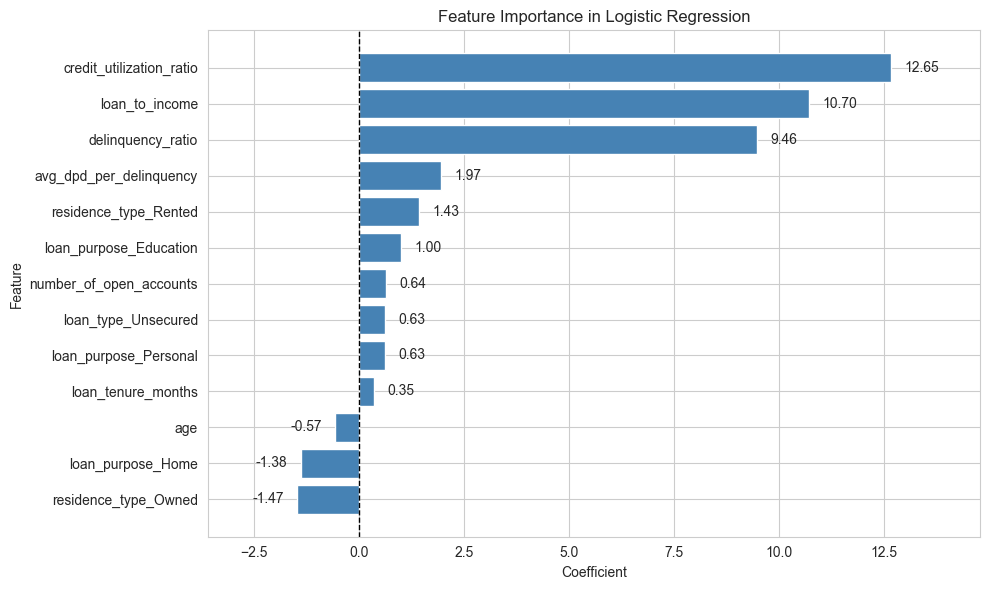

In [199]:
# Extract the feature importance (coefficients) from the trained Logistic Regression model
feature_importance = model.coef_[0]

# Create a DataFrame of feature names and their corresponding coefficients
coef_df = pd.DataFrame(
    {
        "Feature": X_train_encoded.columns,
        "Coefficient": feature_importance
    }
)

# Sort the features by coefficient value
coef_df = coef_df.sort_values(by="Coefficient")

# Plot the feature coefficients
plt.figure(figsize=(10, 6))

bars = plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color="steelblue"
)

# Determine axis limits dynamically
xmin = coef_df["Coefficient"].min()
xmax = coef_df["Coefficient"].max()
padding = (xmax - xmin) * 0.15

plt.xlim(xmin - padding, xmax + padding)

# Add the coefficient value to each bar
offset = padding * 0.15

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + offset if width >= 0 else width - offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=10
    )

# Add a reference line at zero
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)

# Customize the plot
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [200]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.97      0.96     12497



Since there is only a marginal difference in performance between Random Forest and Logistic Regression, we choose **Logistic Regression** as the candidate model for **RandomizedSearchCV**, as it provides better interpretability while achieving comparable predictive performance.

**RandomizedSearch CV for Attempt 1: Logistic Regression**

In [201]:
# Import the required library
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_dist = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["lbfgs", "liblinear", "newton-cg", "saga"]
}

# Initialize the Logistic Regression model
log_reg = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Configure RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Perform hyperparameter tuning
random_search.fit(X_train_encoded, y_train)

# Display the best hyperparameters and cross-validation score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {random_search.best_score_:.4f}")

# Retrieve the best-performing model
best_model = random_search.best_estimator_

# Generate predictions on the test set
y_pred = best_model.predict(X_test_encoded)

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END .............................C=0.0001, solver=lbfgs; total time=   0.1s
[CV] END ............C=0.08858667904100823, solver=newton-cg; total time=   0.3s
[CV] END ............C=0.08858667904100823, solver=newton-cg; total time=   0.3s
[CV] END ............C=0.08858667904100823, solver=newton-cg; total time=   0.3s
[CV] END .............................C=0.0001, solver=lbfgs; total time=   0.1s
[CV] END .............................C=0.0001, solver=lbfgs; total time=   0.1s
[CV] END ...........C=0.012742749857031334, solver=newton-cg; total time=   0.3s
[CV] END ...........C=0.012742749857031334, solver=newton-cg; total time=   0.3s
[CV] END ...........C=0.012742749857031334, solver=newton-cg; total time=   0.2s
[CV] END ...........C=0.004832930238571752, solver=newton-cg; total time=   0.2s
[CV] END .................C=0.08858667904100823, solver=saga; total time=   0.5s
[CV] END .................C=0.08858667904100823,

**RandomizedSearch CV for Attempt 1: Random Forest**

In [202]:
# Import the required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    verbose=1
)

# Configure RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=3
)

# Perform hyperparameter tuning
random_search.fit(X_train_encoded, y_train)

# Display the best hyperparameters and cross-validation score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {random_search.best_score_:.4f}")

# Retrieve the best-performing model
best_model = random_search.best_estimator_

# Generate predictions on the test set
y_pred = best_model.predict(X_test_encoded)

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.1s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.1s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


[CV 1/3] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100;, score=0.754 total time=   4.4s
[CV 2/3] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100;, score=0.739 total time=   4.4s
[CV 3/3] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100;, score=0.756 total time=   4.4s


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


[CV 1/3] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.761 total time=   4.7s


...

[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.2s finished


[CV 3/3] END class_weight=balanced, max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=200;, score=0.763 total time=   4.9s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    5.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
Best Cross-Validation F1 Score: 0.7721
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11423
           1       0.72      0.86      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.85      0.91      0.88     12497
weighted avg       0.96      0.96      0.96     12497



[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.2s finished


**Attempt 2**

1. Logistic Regression & Random Forest
2. Handle Class Imbalance Using Under Sampling

In [203]:
# Import the Random Under Sampler
from imblearn.under_sampling import RandomUnderSampler

# Initialize the Random Under Sampler
rus = RandomUnderSampler(random_state=42)

# Apply random under sampling to balance the training data
X_train_res, y_train_res = rus.fit_resample(X_train_encoded, y_train)

# Display the class distribution after under sampling
y_train_res.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [204]:
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the under-sampled training data
model.fit(X_train_res, y_train_res)

# Generate predictions on the test set
y_pred = model.predict(X_test_encoded)

# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.95      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



In [205]:
# Initialize the Random Forest model using the best hyperparameters
model = RandomForestClassifier(**random_search.best_params_, random_state=42)

# Train the model using the under-sampled training data
model.fit(X_train_res, y_train_res)

# Generate predictions on the test set
y_pred = model.predict(X_test_encoded)

# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.53      0.97      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.95      0.82     12497
weighted avg       0.96      0.92      0.93     12497



**Attempt 3**

1. Logistic Regression
2. Handle Class Imbalance Using SMOTE Tomek
3. Hyperparameter Tuning Using Optuna

In [206]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34199
1    34199
Name: count, dtype: int64

In [207]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [208]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [209]:
# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameter search space
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e4, log=True),
        "solver": trial.suggest_categorical(
            "solver",
            ["lbfgs", "liblinear", "saga", "newton-cg"]
        ),
        "tol": trial.suggest_float("tol", 1e-6, 1e-1, log=True),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    # Initialize the Logistic Regression model
    model = LogisticRegression(
        **params,
        max_iter=10000,
        random_state=42
    )

    # Evaluate the model using cross-validation
    scores = cross_val_score(
        model,
        X_train_smt,
        y_train_smt,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()


# Create the Optuna study
study_logistic = optuna.create_study(direction="maximize")

# Perform hyperparameter optimization
study_logistic.optimize(objective, n_trials=50)

[I 2026-08-01 08:15:25,617] A new study created in memory with name: no-name-2fdb9ae4-4497-4a8e-90cd-64a30695bf38
[I 2026-08-01 08:15:26,095] Trial 0 finished with value: 0.9320793512807639 and parameters: {'C': 0.009617469227801326, 'solver': 'newton-cg', 'tol': 2.0991990869581057e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9320793512807639.
[I 2026-08-01 08:15:26,616] Trial 1 finished with value: 0.9465516832073639 and parameters: {'C': 46.683484470660524, 'solver': 'lbfgs', 'tol': 2.1384948139063546e-06, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9465516832073639.
[I 2026-08-01 08:15:26,949] Trial 2 finished with value: 0.939257161939072 and parameters: {'C': 0.03756630964315972, 'solver': 'lbfgs', 'tol': 0.0001052771983841334, 'class_weight': None}. Best is trial 1 with value: 0.9465516832073639.
[I 2026-08-01 08:15:27,181] Trial 3 finished with value: 0.8717891216944208 and parameters: {'C': 0.00034809881634643205, 'solver': 'lbfgs', 'tol': 0.00

In [210]:
# Display the best trial
print("Best Trial:")

best_trial = study_logistic.best_trial

print(f"F1 Score: {best_trial.value:.4f}")
print("Best Hyperparameters:")

for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

# Initialize the Logistic Regression model using the best hyperparameters
best_model_logistic = LogisticRegression(
    **study_logistic.best_params,
    max_iter=10000,
    random_state=42
)

# Train the model using the SMOTE-Tomek resampled training data
best_model_logistic.fit(X_train_smt, y_train_smt)

# Generate predictions on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

# Display the classification report
print(classification_report(y_test, y_pred))

Best Trial:
F1 Score: 0.9469
Best Hyperparameters:
  C: 2.9807189268362833
  solver: saga
  tol: 4.214837371598952e-06
  class_weight: balanced
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



**Attempt 4**

1. Random Forest
2. Handle Class Imbalance Using SMOTE-Tomek
3. Hyperparameter Tuning Using Optuna

In [211]:
# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 5),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 3),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt"]
        ),
        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True]
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    # Initialize the Random Forest model
    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    # Evaluate the model using cross-validation
    scores = cross_val_score(
        model,
        X_train_smt,
        y_train_smt,
        cv=2,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()


# Create the Optuna study
study_rf = optuna.create_study(direction="maximize")

# Perform hyperparameter optimization
study_rf.optimize(objective, n_trials=20)

[I 2026-08-01 08:15:55,613] A new study created in memory with name: no-name-b76a4e0e-e284-4b90-a3ca-f4340ca7d91d
[I 2026-08-01 08:16:06,024] Trial 0 finished with value: 0.9635806958288247 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9635806958288247.
[I 2026-08-01 08:16:09,391] Trial 1 finished with value: 0.9636796561783421 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9636796561783421.
[I 2026-08-01 08:16:19,863] Trial 2 finished with value: 0.9679482520741961 and parameters: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None}. Best is trial 2 with value: 0.9679482520741961

In [212]:
# Display the best trial
print("Best Trial:")

best_trial = study_rf.best_trial

print(f"F1 Score: {best_trial.value:.4f}")
print("Best Hyperparameters:")

for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

# Initialize the Random Forest model using the best hyperparameters
best_model_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

# Train the model using the SMOTE-Tomek resampled training data
best_model_rf.fit(X_train_smt, y_train_smt)

# Generate predictions on the test set
y_pred = best_model_rf.predict(X_test_encoded)

# Display the classification report
print(classification_report(y_test, y_pred))

Best Trial:
F1 Score: 0.9742
Best Hyperparameters:
  n_estimators: 100
  max_depth: 19
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  bootstrap: True
  class_weight: balanced
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     11423
           1       0.69      0.88      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.84      0.92      0.88     12497
weighted avg       0.96      0.96      0.96     12497



#### **5. Model Evaluation**

**ROC/AUC**

In [213]:
y_pred = best_model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [214]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75426771e-05,
        8.75426771e-05]),
 array([0.        , 0.0009311 , 0.16201117, 0.16201117, 0.17690875]),
 array([       inf, 1.        , 0.99942927, 0.99942396, 0.99930466]))

In [215]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.983677692316345

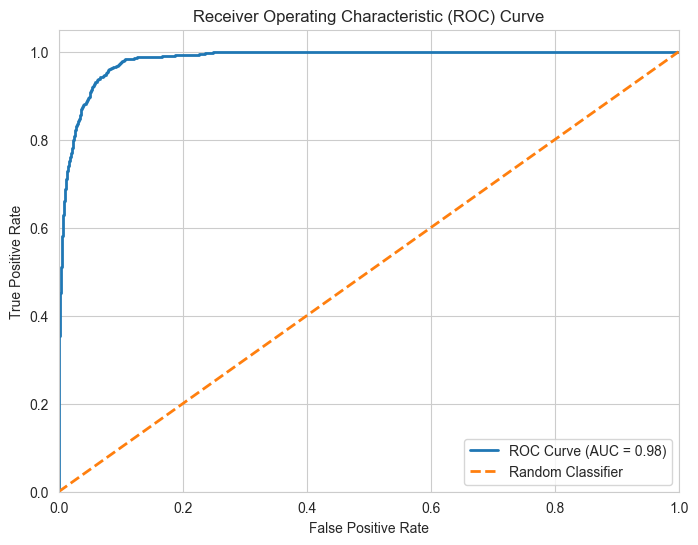

In [216]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {area:.2f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# Customize the plot
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")

plt.savefig("../images/receiver_operating_characteristic_curve.png", dpi=300, bbox_inches="tight")
plt.show()

**Model Evaluation: Rankordering, KS statistic, Gini coeff**

In [217]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})

In [218]:
df_eval.head(5)

,Default Truth,Default Probability
19205,0,0.535
15514,0,0.000
30367,0,0.006
35347,0,0.007
41814,1,0.922


In [219]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')

In [220]:
df_eval.head(5)

,Default Truth,Default Probability,Decile
19205,0,0.535,8
15514,0,0.000,2
30367,0,0.006,6
35347,0,0.007,6
41814,1,0.922,9


In [221]:
df_eval[df_eval.Decile==8]['Default Probability'].describe()

count   1250.000
mean       0.485
std        0.182
min        0.215
25%        0.317
50%        0.467
75%        0.640
max        0.819
Name: Default Probability, dtype: float64

In [222]:
# Summarize the prediction results by decile
df_decile = (
    df_eval.groupby("Decile")
    .apply(
        lambda x: pd.Series({
            "Minimum Probability": x["Default Probability"].min(),
            "Maximum Probability": x["Default Probability"].max(),
            "Events": x["Default Truth"].sum(),
            "Non-events": x["Default Truth"].count() - x["Default Truth"].sum(),
        }),
        include_groups=False
    )
    .reset_index()
)

# Display the decile summary
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1249.000
3,3,0.000,0.000,0.000,1250.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.004,0.000,1249.000
6,6,0.004,0.030,5.000,1245.000
7,7,0.030,0.214,10.000,1239.000
8,8,0.215,0.819,162.000,1088.000
9,9,0.819,1.000,897.000,353.000


In [223]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1250.000,0.000,100.000
2,2,0.000,0.000,0.000,1249.000,0.000,100.000
3,3,0.000,0.000,0.000,1250.000,0.000,100.000
4,4,0.000,0.001,0.000,1250.000,0.000,100.000
5,5,0.001,0.004,0.000,1249.000,0.000,100.000
6,6,0.004,0.030,5.000,1245.000,0.400,99.600
7,7,0.030,0.214,10.000,1239.000,0.801,99.199
8,8,0.215,0.819,162.000,1088.000,12.960,87.040
9,9,0.819,1.000,897.000,353.000,71.760,28.240


In [224]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.819,1.000,897.000,353.000,71.760,28.240
1,8,0.215,0.819,162.000,1088.000,12.960,87.040
2,7,0.030,0.214,10.000,1239.000,0.801,99.199
3,6,0.004,0.030,5.000,1245.000,0.400,99.600
4,5,0.001,0.004,0.000,1249.000,0.000,100.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [225]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.819,1.000,897.000,353.000,71.760,28.240,897.000,353.000
1,8,0.215,0.819,162.000,1088.000,12.960,87.040,1059.000,1441.000
2,7,0.030,0.214,10.000,1239.000,0.801,99.199,1069.000,2680.000
3,6,0.004,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000


In [226]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.819,1.000,897.000,353.000,71.760,28.240,897.000,353.000,83.520,3.090
1,8,0.215,0.819,162.000,1088.000,12.960,87.040,1059.000,1441.000,98.603,12.615
2,7,0.030,0.214,10.000,1239.000,0.801,99.199,1069.000,2680.000,99.534,23.461
3,6,0.004,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000,100.000,34.361
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000


In [227]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.819,1.000,897.000,353.000,71.760,28.240,897.000,353.000,83.520,3.090,80.429
1,8,0.215,0.819,162.000,1088.000,12.960,87.040,1059.000,1441.000,98.603,12.615,85.988
2,7,0.030,0.214,10.000,1239.000,0.801,99.199,1069.000,2680.000,99.534,23.461,76.073
3,6,0.004,0.030,5.000,1245.000,0.400,99.600,1074.000,3925.000,100.000,34.361,65.639
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295,54.705
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237,43.763
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000,0.000


#### Decile Analysis and Rank Ordering

To evaluate whether the model satisfies **rank ordering**, we examine whether higher deciles, which represent higher predicted probabilities of default, contain higher event rates than lower deciles. A well-performing credit risk model should assign most default cases to the highest-risk deciles, with event rates decreasing progressively across the remaining deciles.

In this credit risk use case:

* **Events** represent **bad customers** (borrowers who default).
* **Non-events** represent **good customers** (borrowers who do not default).

The definitions of events and non-events may vary depending on the business problem. For example, in a marketing campaign, customers who respond to an offer may be treated as events (good outcomes), while non-responders are considered non-events.

#### Insights from the Decile Table

* **Top deciles:** The highest-risk decile (Decile 9) contains an event rate of **71.76%**, indicating that the model successfully concentrates a large proportion of default cases among borrowers with the highest predicted risk. Decile 8 contributes an additional **12.96%** of events, resulting in a cumulative event capture of **98.60%** within the top two deciles.

* **Middle deciles:** Deciles 7 and 6 exhibit a substantial decline in event rates, indicating that the model effectively separates high-risk borrowers from moderate-risk borrowers.

* **Lower deciles:** Deciles 5 through 0 contain no default events, with all observations classified as non-events. This demonstrates that the model assigns very low default probabilities to borrowers with low credit risk.

#### KS Statistic

The **Kolmogorov–Smirnov (KS) statistic** measures the maximum separation between the cumulative distributions of events and non-events. The model achieves its highest KS value of **85.99%** at **Decile 8**, indicating excellent discriminatory power between defaulting and non-defaulting borrowers.

A KS statistic above **40%** is generally considered indicative of a strong predictive model. Furthermore, the maximum KS occurring within the **top three deciles** suggests that the model effectively ranks borrowers according to their likelihood of default, demonstrating excellent rank ordering and predictive performance.

In [228]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.983677692316345
Gini Coefficient: 0.9673553846326901


#### ROC-AUC and Gini Coefficient

An **AUC of 0.98** indicates that the model has an excellent ability to distinguish between defaulting and non-defaulting borrowers. This suggests that the model can correctly rank high-risk and low-risk applicants with a very high degree of accuracy.

The corresponding **Gini coefficient of 0.97** further confirms the model's strong discriminatory power and excellent rank ordering capability.

The **Gini coefficient** ranges from **-1 to 1**, where:

* A value close to **1** indicates excellent predictive performance.
* A value of **0** indicates no discriminatory power, equivalent to random guessing.
* A value close to **-1** indicates perfectly incorrect predictions.


**Finalize The Model and Visualize Feature Importance**

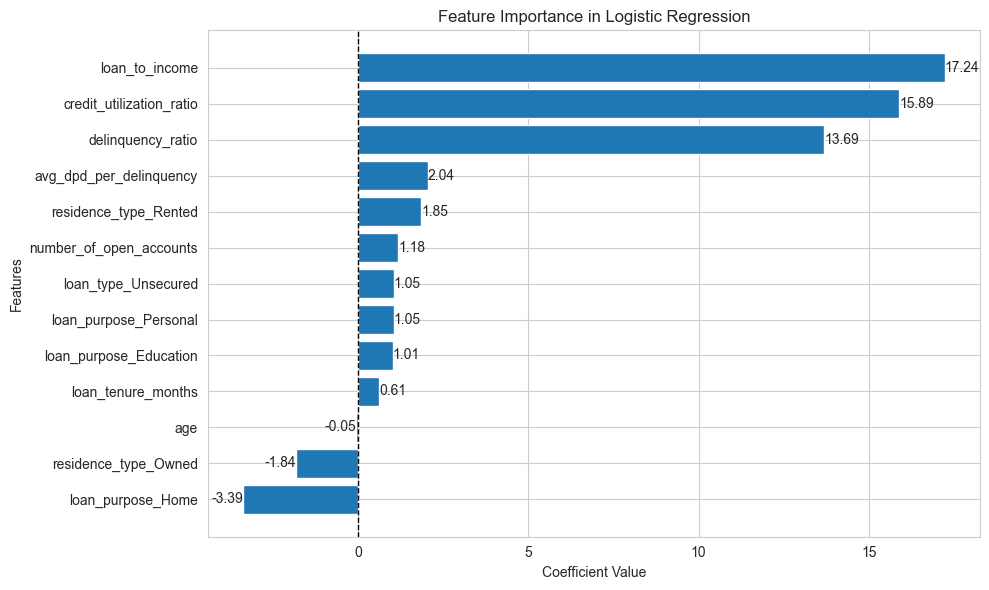

In [229]:
final_model = best_model_logistic

# Extract the feature coefficients from the final Logistic Regression model
feature_importance = best_model_logistic.coef_[0]

# Create a DataFrame of feature coefficients
coef_df = pd.DataFrame(
    {
        "Coefficient": feature_importance
    },
    index=X_train_encoded.columns
)

# Sort the coefficients for visualization
coef_df = coef_df.sort_values(by="Coefficient")

# Plot the feature coefficients
plt.figure(figsize=(10, 6))

bars = plt.barh(
    coef_df.index,
    coef_df["Coefficient"]
)

# Add a reference line at zero
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)

# Display the coefficient values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right"
    )

# Customize the plot
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

# Adjust the layout and display the plot
plt.tight_layout()

plt.savefig("../images/feature_importance_in_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Save the Model**

In [230]:
X_test_encoded.head(5)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,True,False,False,True,False,False
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,True,False,True,False,False,False
30367,0.231,0.547,0.667,0.828,0.180,0.000,0.000,True,False,False,False,False,False
35347,0.365,0.755,1.000,0.485,0.571,0.024,0.700,True,False,False,True,False,False
41814,0.577,0.717,0.667,0.980,0.407,0.107,0.636,False,False,False,True,False,False


In [231]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [232]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [233]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [234]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, "../app/artifacts/model_data.joblib")

['../app/artifacts/model_data.joblib']

In [235]:
final_model.coef_, final_model.intercept_

(array([[-0.05270931,  0.61346867,  1.17765051, 15.89376781, 17.23948825,
         13.68619776,  2.04121635, -1.83906429,  1.84811592,  1.01398239,
         -3.3904355 ,  1.04665899,  1.04665899]]),
 array([-20.68904229]))